# 🩺 Diabetes Prediction

This notebook presents a complete machine learning pipeline developed for competition on health data. The goal is to predict the probability of a diabetes diagnosis from a set of patient health indicators, using a synthetically generated dataset derived from the Diabetes Health Indicators Dataset.

The work is structured to cover the full ML workflow: exploratory analysis, preprocessing, feature engineering, model training and comparison, evaluation and final prediction.

**Source competition**: https://www.kaggle.com/competitions/playground-series-s5e12

**Author**: Sansone Lorenzo — University of Bologna, Academic Year 2025/2026

## Notebook Structure

1. Introduction
2. Setup
3. Exploratorion of Data & Cleaning
4. Preprocessing Dataset
5. Models & Parameters Definition
6. Model Training
7. Evaluation & Comparison
8. References

## **1. Introduction**

This notebook addresses a binary classification problem: **predicting the probability that a patient has been diagnosed with diabetes**, based on a set of health indicators.

The dataset was synthetically generated from a deep learning model trained on the [Diabetes Health Indicators Dataset](https://www.kaggle.com/datasets/mohankrishnathalla/diabetes-health-indicators-dataset/data), meaning feature distributions are close — but not identical — to the original.

---

### 1.1 Objective
The goal of this competition is to leverage machine learning techniques to predict the probability that a patient will be diagnosed with diabetes based on various clinical and demographic features.

Predict the **probability** of `diagnosed_diabetes` for each sample in the test set.  
The primary evaluation metric is **ROC-AUC** (Area Under the Receiver Operating Characteristic Curve).

---

### 1.2 Files
| File | Description |
|---|---|
| `train.csv` | Training set with features and target label |
| `test.csv` | Test set — features only, no labels |
| `sample_submission.csv` | Expected output format for predictions |


## **2. Setup**

### 2.1 Install Missing Dependencies (if needed)

The cell below installs any libraries not available by default in the environment.  
If you're running this on Kaggle or Google Colab, most of these are pre-installed.

In [1]:
# Install libraries not available by default
# Uncomment as needed depending on the environment

# !pip install numpy
# !pip install -U scikit-learn
# !pip install pandas
# !pip install seaborn
# !pip insall matplotlib

### 2.2 Import Libraries

In [2]:
# ── Core ──────────────────────────────────────────────────────────────────────
import numpy as np                          # Numerical operations
import pandas as pd                         # Data manipulation
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder # Encoding features
from sklearn.model_selection import train_test_split # Dataset split
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.svm import SVC
from sklearn.linear_model import Perceptron
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
import lightgbm as lgb
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt             # Base plotting library
import matplotlib.ticker as mticker
import seaborn as sns                       # Statistical visualizations

# ── Utilities ─────────────────────────────────────────────────────────────────
import os
import time
from IPython.display import display
import warnings


warnings.simplefilter(action='ignore', category=FutureWarning)
print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


### 2.3 Global Configuration

Centralizing configuration constants makes experiments reproducible and easy to tweak.
- `RANDOM_STATE`: fixes all stochastic operations so results are reproducible
- `TRAIN`:
- `N_FOLDS`: number of folds for cross-validation
- `TEST_SIZE`: fraction of training data used for the local validation set
- `TARGET`: name of the column we want to predict

In [3]:
# ── Reproducibility ───────────────────────────────────────────────────────────
RANDOM_STATE = 42           # Fixed seed for all random operations
np.random.seed(RANDOM_STATE)

# ── Hold-Out Method ───────────────────────────────────────────────────────────
TRAIN_SIZE = 0.67

# ── Cross-Validation ──────────────────────────────────────────────────────────
N_FOLDS = 5                 # Number of StratifiedKFold folds

# ── Dataset ───────────────────────────────────────────────────────────────────
TARGET = 'diagnosed_diabetes'   # Name of the target column
DATA_DIR = '/kaggle/input/competitions/playground-series-s5e12' #Adjust according the dataset location 

print(f"Configuration set:")
print(f"   Random state : {RANDOM_STATE}")
print(f"   CV folds     : {N_FOLDS}")
print(f"   Target col   : '{TARGET}'")

Configuration set:
   Random state : 42
   CV folds     : 5
   Target col   : 'diagnosed_diabetes'


### 2.4 Load the Data

We load the train CSV file (supervised data) provided by the competition:
- `train.csv`: used to train, validate and test our models

In [4]:
# ── Load Datasets ─────────────────────────────────────────────────────────────
df = pd.read_csv(f'{DATA_DIR}/train.csv')

print("✅ Files loaded successfully.")
print(f"\n{'Dataset':<22} {'Rows':>8} {'Columns':>10}")
print("-" * 42)
print(f"{'train.csv':<22} {df.shape[0]:>8} {df.shape[1]:>10}")

✅ Files loaded successfully.

Dataset                    Rows    Columns
------------------------------------------
train.csv                700000         26


## **3. Exploration of Data & Cleaning**
Before any statistical analysis, we take a first look at the raw data to verify
it matches what the competition describes: correct number of rows and columns,
expected feature names, and sensible values at a glance.

### 3.1 General information about dataset
The dataset includes patient profiles with features based on **demographics**, **lifestyle habits**, **family history** and **clinical measurements** that are well-established indicators of diabetes risk.

All data has been synthetically generated using statistical distributions and correlations derived from real-world medical research studies. This approach ensures:

- 🔒 Privacy preservation (no real patient data used)
- 📊 Realistic health patterns and relationships
- 🧪 Suitability for machine learning, analysis, and experimentation

Display th list of columns

In [5]:
df.columns

Index(['id', 'age', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi',
       'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate',
       'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol',
       'triglycerides', 'gender', 'ethnicity', 'education_level',
       'income_level', 'smoking_status', 'employment_status',
       'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'diagnosed_diabetes'],
      dtype='object')

#### Column Descriptions:

The dataset contains **26 columns** (25 features + 1 target), covering four
domains: clinical measurements, lifestyle habits, demographic information and personal medical history.

Note: since the `id` is just a unique row identifier, it carries no predictive value and it's not considered in the following description of the columns. So totally, we have 25 columns (24 features + 1 target) to analyze


##### 📊 Clinical Measurements
| Column | Type | Description |
|--------|------|-------------|
| `bmi` | float64 | Body Mass Index (kg/m²). |
| `waist_to_hip_ratio` | float64 | Ratio of waist circumference to hip circumference. |
| `systolic_bp` | int64 | Systolic blood pressure (mmHg) |
| `diastolic_bp` | int64 | Diastolic blood pressure (mmHg) |
| `heart_rate` | int64 | Resting heart rate (bpm - beats per minute). |
| `cholesterol_total` | int64 | Total cholesterol level (mg/dL). |
| `hdl_cholesterol` | int64 | High-Density Lipoprotein (HDL) cholesterol (mg/dL), commonly called "good" cholesterol. |
| `ldl_cholesterol` | int64 | Low-Density Lipoprotein cholesterol (mg/dL), commonly called "bad" cholesterol. |
| `triglycerides` | int64 | Triglyceride level (mg/dL), the most common type of fat in the blood.  |

---

##### 🏃 Lifestyle Habits
| Column | Type | Description |
|--------|------|-------------|
| `alcohol_consumption_per_week` | int64 | Number of alcoholic drinks consumed per week. |
| `physical_activity_minutes_per_week` | int64 | Total minutes of physical activity per week. |
| `diet_score` | float64 | A score reflecting overall dietary quality. Higher scores indicate a healthier diet. |
| `sleep_hours_per_day` | float64 | Average daily sleep hours. |
| `screen_time_hours_per_day` | float64 | Average daily hours spent on screens. |
| `smoking_status` | object | Smoking behavior ('Never', 'Former', 'Current') |

---

##### 👤 Demographic Information
| Column | Type | Description |
|--------|------|-------------|
| `age` | int64 | Age of the patient in years. |
| `gender` | object | Biological sex of the patient ( 'Male', 'Female', 'Other'). |
| `ethnicity` | object | Ethnic background ('White', 'Hispanic', 'Black', 'Asian', 'Other'). |
| `education_level` | object | Highest level of education completed. ('No formal', 'Highschool', 'Graduate', 'Postgraduate') |
| `income_level` | object | Income of the patient.  Likely **ordinal** ( 'Low' < 'Lower-Middle' < 'Middle' < 'Upper-Middle'< 'High' ) |
| `employment_status` | object | Current employment situation ('Employed', 'Unemployed', 'Retired', 'Student'). |

---

##### 🏥 Medical History
| Column | Type | Description |
|--------|------|-------------|
| `family_history_diabetes` | int64 | Binary flag (0 = No, 1 = Yes) indicating family history of diabetes. |
| `hypertension_history` | int64 | Binary flag (0 = No, 1 = Yes) indicating a diagnosis of hypertension. |
| `cardiovascular_history` | int64 | Binary flag (0 = No, 1 = Yes) indicating a history of cardiovascular disease. |

---

##### 🎯 Target Variable
| Column | Type | Description |
|--------|------|-------------|
| `diagnosed_diabetes` | float64 | Binary target variable (0.0 = No diabetes, 1.0 = Diabetes). This is the variable our models will learn to predict. |

Display the first 5 rows to get a feel for the data:

In [6]:
df.head()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
0,0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,...,Female,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,1.0
1,1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,...,Female,White,Highschool,Upper-Middle,Never,Employed,0,0,0,1.0
2,2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,...,Male,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,0.0
3,3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,...,Female,White,Highschool,Lower-Middle,Current,Employed,0,1,0,1.0
4,4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,...,Male,White,Highschool,Upper-Middle,Never,Retired,0,1,0,1.0


`df.info()` gives a compact structural summary of the dataframe:
- total number of rows and columns
- each column's name, non-null count, and dtype
- memory usage

In [7]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700000 entries, 0 to 699999
Data columns (total 26 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   id                                  700000 non-null  int64  
 1   age                                 700000 non-null  int64  
 2   alcohol_consumption_per_week        700000 non-null  int64  
 3   physical_activity_minutes_per_week  700000 non-null  int64  
 4   diet_score                          700000 non-null  float64
 5   sleep_hours_per_day                 700000 non-null  float64
 6   screen_time_hours_per_day           700000 non-null  float64
 7   bmi                                 700000 non-null  float64
 8   waist_to_hip_ratio                  700000 non-null  float64
 9   systolic_bp                         700000 non-null  int64  
 10  diastolic_bp                        700000 non-null  int64  
 11  heart_rate                

**Observations:**

The dataset contains **700,000 rows and 26 columns** with **no missing values** across
any feature.

The columns fall into three groups by dtype:

- **Continuous numerical** (`float64`)

- **Discrete numerical** (`int64`)

- **Categorical** (`object`)


The **target** `diagnosed_diabetes` is stored as `float64` rather than `int64`. It should contain only `0.0` and `1.0` values (see later).

The total memory footprint is **138.9 MB**, manageable in-memory without
any chunking strategy.

Overall check of type and non-unique features:

In [8]:
pd.DataFrame({
    'dtype':   df.dtypes,
    'nunique': df.nunique(),
    'sample':  [df[c].dropna().iloc[0] if df[c].notna().any() else None for c in df.columns]
})

,dtype,nunique,sample
id,int64,700000,0
age,int64,71,31
alcohol_consumption_per_week,int64,9,1
physical_activity_minutes_per_week,int64,565,45
diet_score,float64,99,7.7
sleep_hours_per_day,float64,69,6.8
screen_time_hours_per_day,float64,151,6.1
bmi,float64,231,33.4
waist_to_hip_ratio,float64,36,0.93
systolic_bp,int64,71,112


As it's written before the **target** `diagnosed_diabetes` contains only `0.0` and `1.0` values.


Check the **object** features:

In [9]:
categorical_cols = df.select_dtypes('object').columns.to_list()

# category values with relative frequencies (to spot class imbalance inside a feature)
for col in categorical_cols:
    print(f"\n \033[1m--- 📋 {col}  ({len(df[col].unique())} unique elements)\033[0m ---")
    print(df[col].value_counts(normalize=True, dropna=False).mul(100).round(2).astype(str) + ' %')


 --- 📋 gender  (3 unique elements) ---
gender
Female    51.89 %
Male      47.58 %
Other      0.53 %
Name: proportion, dtype: object

 --- 📋 ethnicity  (5 unique elements) ---
ethnicity
White       55.16 %
Hispanic    18.57 %
Black       15.19 %
Asian        8.59 %
Other        2.49 %
Name: proportion, dtype: object

 --- 📋 education_level  (4 unique elements) ---
education_level
Highschool      49.16 %
Graduate        37.32 %
Postgraduate    11.38 %
No formal        2.14 %
Name: proportion, dtype: object

 --- 📋 income_level  (5 unique elements) ---
income_level
Middle          41.51 %
Lower-Middle    25.51 %
Upper-Middle    18.26 %
Low             12.26 %
High             2.46 %
Name: proportion, dtype: object

 --- 📋 smoking_status  (3 unique elements) ---
smoking_status
Never      70.64 %
Current    14.77 %
Former      14.6 %
Name: proportion, dtype: object

 --- 📋 employment_status  (4 unique elements) ---
employment_status
Employed      73.74 %
Retired       16.53 %
Unemployed   

Find hidden categoricals among the int64 and float64 columns. Many features in this dataset are likely binary flags (family history, etc.) 

In [10]:
#values with relative frequencies (to spot class imbalance inside a feature)
for col in df.select_dtypes(['int64','float64']).columns.to_list():
    n = df[col].nunique()
    if n <= 20:
        print(f"\n \033[1m--- 📋 {col} ({len(df[col].unique())} unique elements) --- \033[0m")
        print(df[col].value_counts(normalize=True, dropna=False).mul(100).round(2).astype(str) + ' %')


 --- 📋 alcohol_consumption_per_week (9 unique elements) --- 
alcohol_consumption_per_week
2    35.23 %
1    35.19 %
3    19.65 %
4     7.57 %
5      1.9 %
6     0.39 %
7     0.06 %
8     0.01 %
9      0.0 %
Name: proportion, dtype: object

 --- 📋 family_history_diabetes (2 unique elements) --- 
family_history_diabetes
0    85.06 %
1    14.94 %
Name: proportion, dtype: object

 --- 📋 hypertension_history (2 unique elements) --- 
hypertension_history
0    81.8 %
1    18.2 %
Name: proportion, dtype: object

 --- 📋 cardiovascular_history (2 unique elements) --- 
cardiovascular_history
0    96.97 %
1     3.03 %
Name: proportion, dtype: object

 --- 📋 diagnosed_diabetes (2 unique elements) --- 
diagnosed_diabetes
1.0    62.33 %
0.0    37.67 %
Name: proportion, dtype: object


Check for any duplicate row:

In [11]:
print(f"Exact duplicates: {df.drop(columns='id').duplicated().sum()}")


Exact duplicates: 0


The **describe** method of pandas dataframes gives a short summary

In [12]:
df.describe()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
count,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000
mean,349999.500000,50.359734,2.072411,80.230803,5.963695,7.002200,6.012733,25.874684,0.858766,116.294193,75.440924,70.167749,186.818801,53.823214,102.905854,123.081850,0.149401,0.181990,0.030324,0.623296
std,202072.738554,11.655520,1.048189,51.195071,1.463336,0.901907,2.022707,2.860705,0.037980,11.010390,6.825775,6.938722,16.730832,8.266545,19.022416,24.739397,0.356484,0.385837,0.171478,0.484560
min,0.000000,19.000000,1.000000,1.000000,0.100000,3.100000,0.600000,15.100000,0.680000,91.000000,51.000000,42.000000,117.000000,21.000000,51.000000,31.000000,0.000000,0.000000,0.000000,0.000000
25%,174999.750000,42.000000,1.000000,49.000000,5.000000,6.400000,4.600000,23.900000,0.830000,108.000000,71.000000,65.000000,175.000000,48.000000,89.000000,106.000000,0.000000,0.000000,0.000000,0.000000
50%,349999.500000,50.000000,2.000000,71.000000,6.000000,7.000000,6.000000,25.900000,0.860000,116.000000,75.000000,70.000000,187.000000,54.000000,103.000000,123.000000,0.000000,0.000000,0.000000,1.000000
75%,524999.250000,58.000000,3.000000,96.000000,7.000000,7.600000,7.400000,27.800000,0.880000,124.000000,80.000000,75.000000,199.000000,59.000000,116.000000,139.000000,0.000000,0.000000,0.000000,1.000000
max,699999.000000,89.000000,9.000000,747.000000,9.900000,9.900000,16.500000,38.400000,1.050000,163.000000,104.000000,101.000000,289.000000,90.000000,205.000000,290.000000,1.000000,1.000000,1.000000,1.000000


### 3.2 Clean data

Check for NaN or null values:

In [13]:
print('NaN count:', df.isnull().sum().sum(), '\n')
df.isnull().sum()

NaN count: 0 



id                                    0
age                                   0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
smoking_status                        0
employment_status                     0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0


`NaN count: 0` across all 26 columns: no rows need to be removed for missing data. There aren't any null or nan values

### 3.3 Target Variable Distribution & Class Balance

Before any modeling decision we need to understand how the two classes are distributed.
A strong imbalance would force us to use stratified splits, class-weighting, or resampling
techniques; a near-balanced target lets us train with standard procedures.

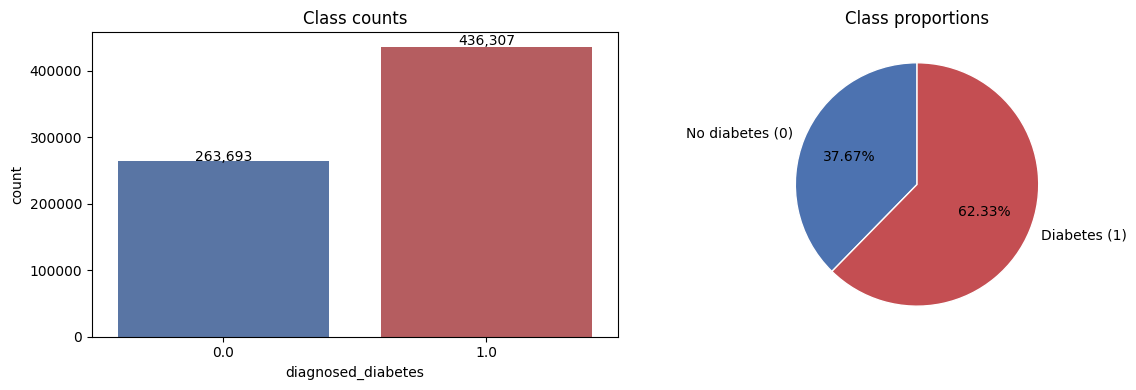

0 (no diabetes): 263693.00
1 (yes diabetes): 436307.00
Positive/Negative ratio: 1.65


In [14]:
# Plot class distribution of the target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Countplot
counts = df[TARGET].value_counts().sort_index() # Take the counts of target values
sns.countplot(x=TARGET, data=df, ax=axes[0], palette=['#4C72B0', '#C44E52']) # Compute the histogram
axes[0].set_title('Class counts')
axes[0].set_xlabel('diagnosed_diabetes')
axes[0].set_ylabel('count')

# Text over the columns
no_diagn = 0
yes_diagn = 1
axes[0].text(0, counts.values[no_diagn] + counts.values[no_diagn]*0.005, f'{counts.values[no_diagn]:,}', ha='center', fontsize=10)
axes[0].text(1, counts.values[yes_diagn] + counts.values[yes_diagn]*0.005, f'{counts.values[yes_diagn]:,}', ha='center', fontsize=10)

# Pieplot with percentages
axes[1].pie(counts.values,
            labels=['No diabetes (0)', 'Diabetes (1)'],
            autopct='%1.2f%%',
            colors=['#4C72B0', '#C44E52'],
            startangle=90,
            wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Class proportions')

plt.tight_layout()
plt.show()

ratio = counts[1.0] / counts[0.0]
print(f"0 (no diabetes): {counts[0.0]:.2f}")
print(f"1 (yes diabetes): {counts[1.0]:.2f}")
print(f"Positive/Negative ratio: {ratio:.2f}")

**Observations:**

- Class proportions: **62.33%** positives (`1.0`), **37.67%** negatives (`0.0`).
- Positive / negative ratio: **1.65**.
- Target is **mildly imbalanced**, with the positive class as majority

### 3.4 Numerical Features — Univariate Distributions

We separate truly *continuous* numerical features from *binary* flags (already inspected
above) and plot a histogram + KDE for each one to inspect the shape, symmetry, and the presence of suspicious peaks.

In [15]:
# Continuous numerical features (exclude id, target, binary flags, and low-card discretes)
binary_cols = ['family_history_diabetes', 'hypertension_history', 'cardiovascular_history']
discrete_cols = ['alcohol_consumption_per_week']
numeric_cols = [c for c in df.select_dtypes(include=['int64', 'float64']).columns
                if c not in ['id', TARGET] + binary_cols + discrete_cols]

print(f"Continuous numerical features ({len(numeric_cols)}):")
print(numeric_cols)

Continuous numerical features (14):
['age', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides']


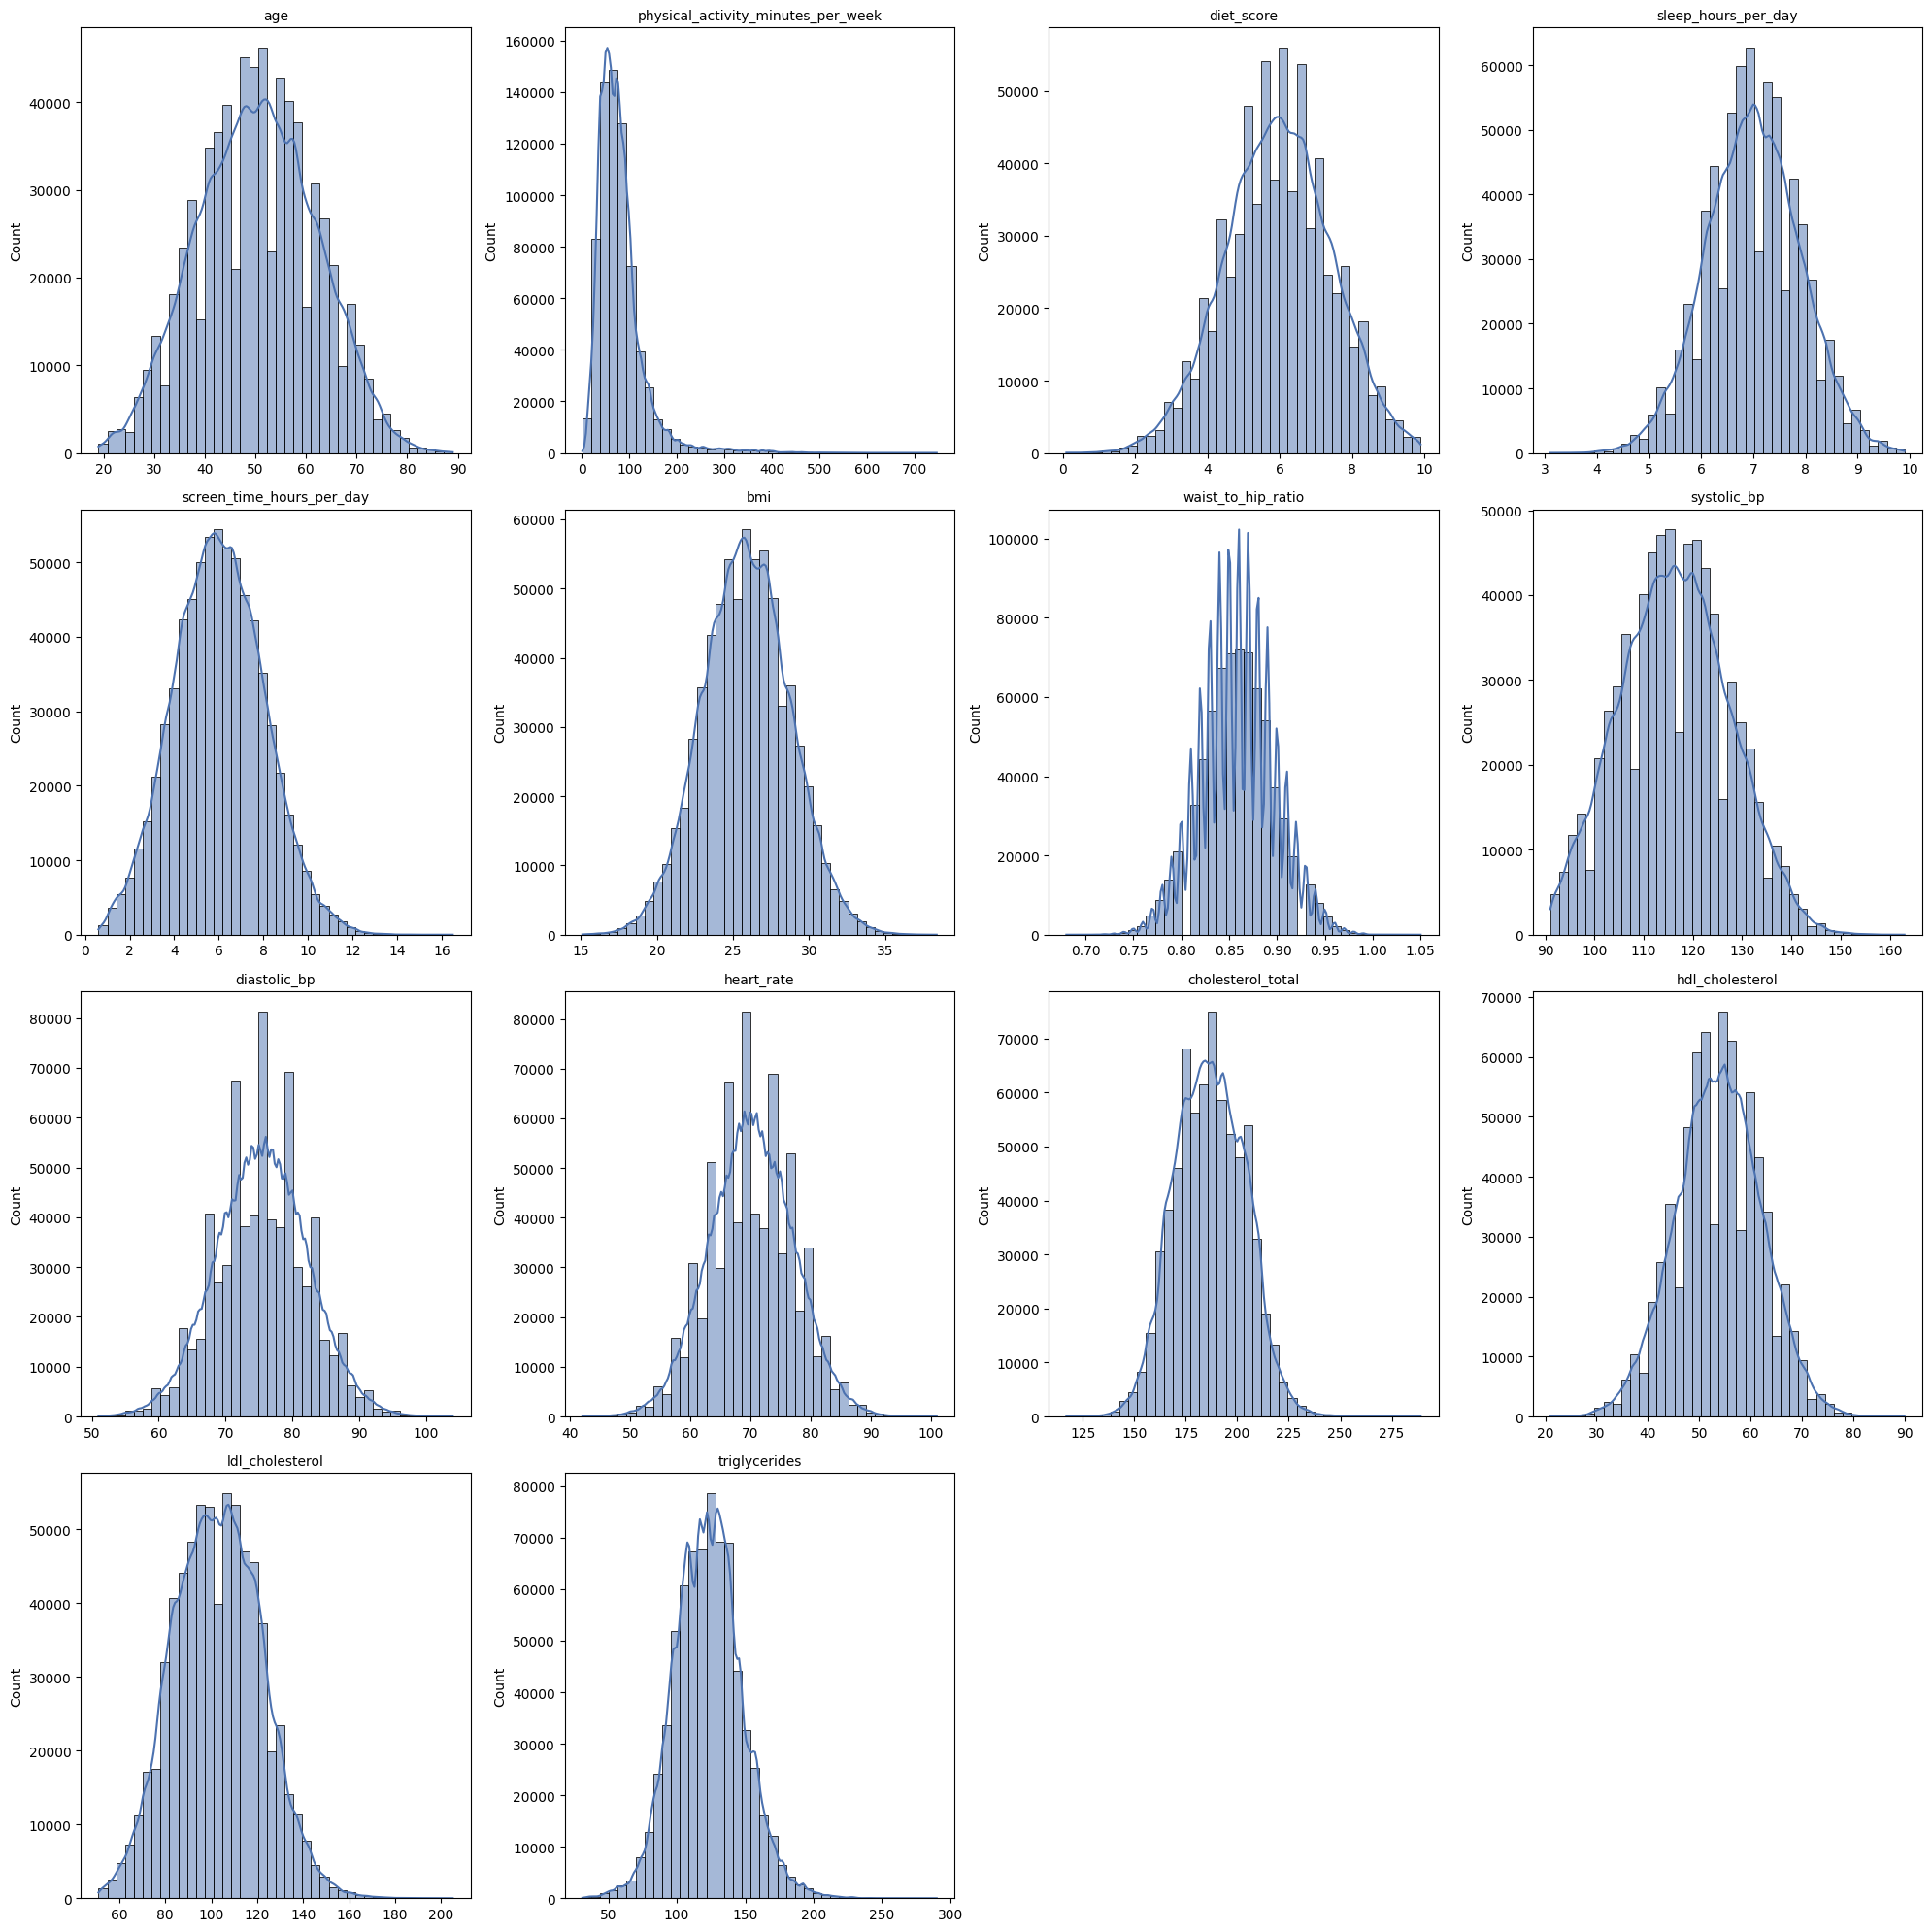

In [16]:
# Histograms with KDE for every continuous numerical feature
n_cols = 4
n_rows = 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 20))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='#4C72B0', bins=40)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

# Hide unused axes
for j in range(len(numeric_cols), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

**Observation:**
- Most clinical features (`bmi`, `systolic_bp`, `diastolic_bp`, `heart_rate`,
  `cholesterol_total`, `hdl_cholesterol`, `ldl_cholesterol`, `triglycerides`,
  `waist_to_hip_ratio`) are roughly **bell-shaped**.
- `physical_activity_minutes_per_week` shows a **strong right-skew** with a long tail
  (a few people training >250 min/week).
- `diet_score`, `sleep_hours_per_day`, `screen_time_hours_per_day` look roughly
  symmetric.
- `age` is distributed between 19 and 89.

### 3.5 Outlier Detection (Boxplots + IQR rule)

We use the **interquartile range (IQR) rule**: a point is flagged as an outlier when it
falls outside `[Q1 − 1.5·IQR, Q3 + 1.5·IQR]`. The boxplots provide a visual confirmation;
the table quantifies how many points are flagged per feature.

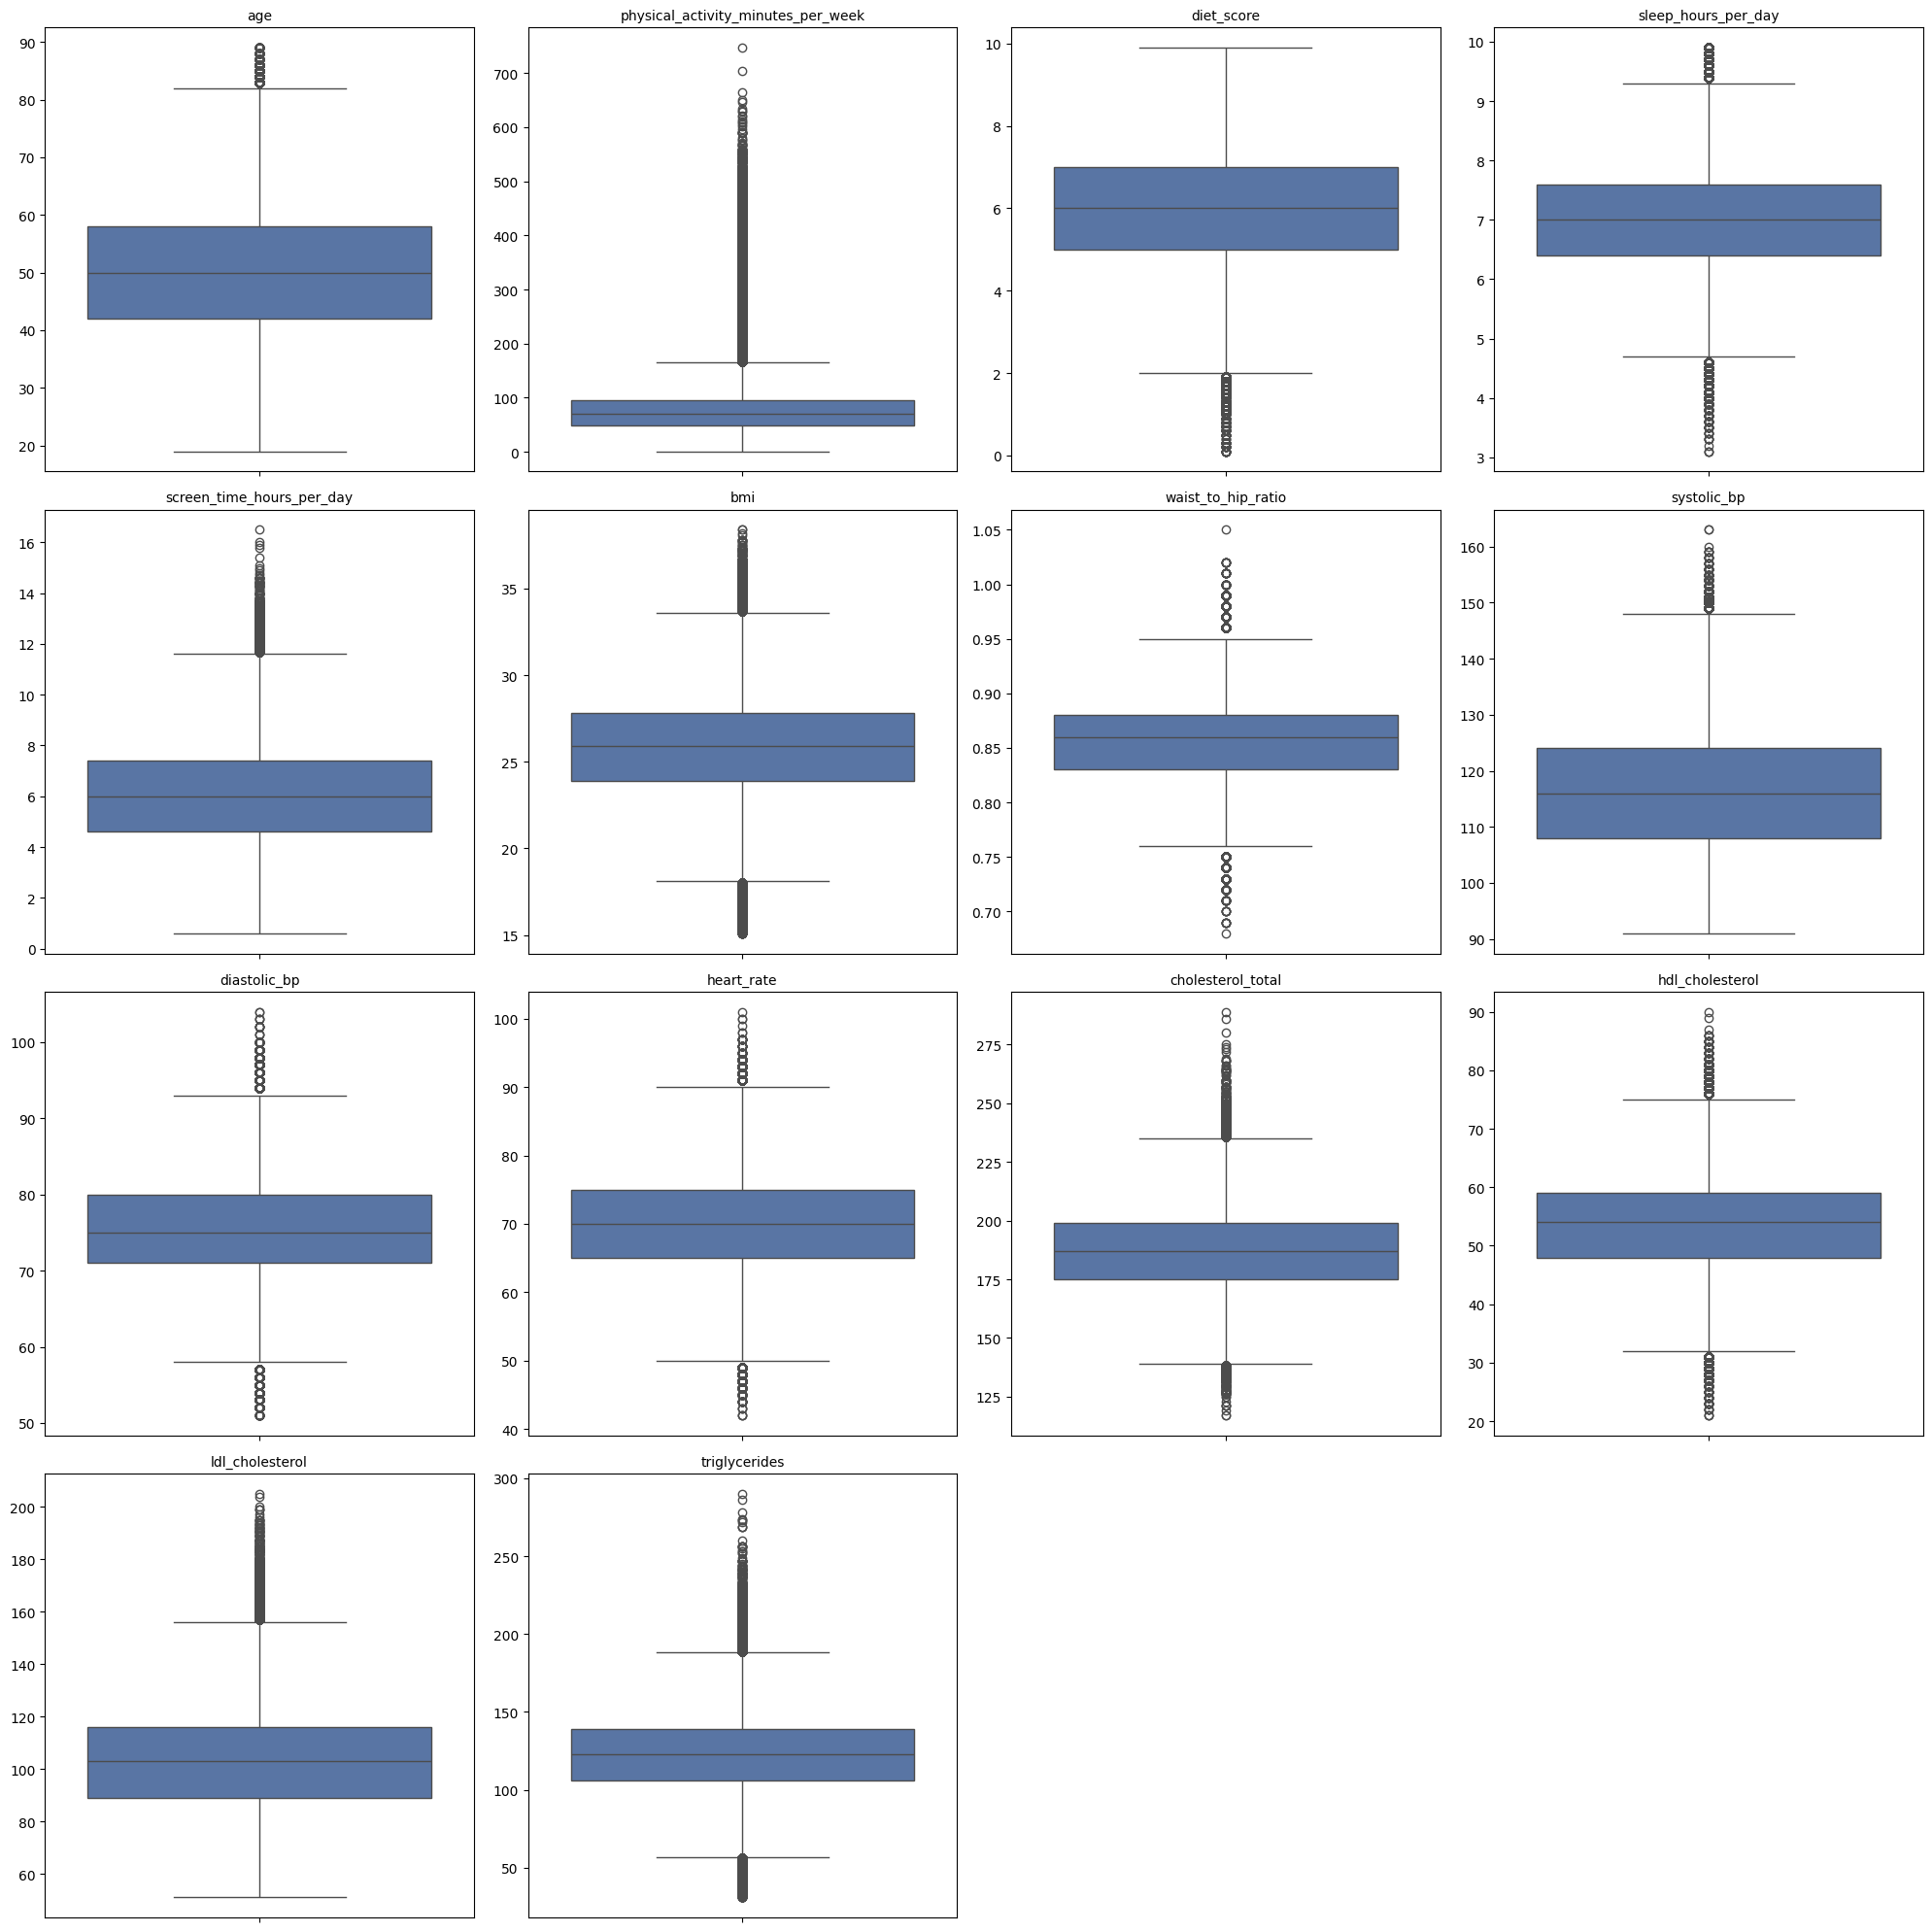

In [17]:
# Boxplots verticali per ogni feature numerica continua
n_cols = 4
n_rows = 4
plt.figure(figsize=(20, 20))

for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    
    sns.boxplot(y=df[col], color='#4C72B0')
    
    plt.title(col, fontsize=10)
    plt.ylabel('')

plt.tight_layout()
plt.show()

In [18]:
# IQR-based outlier detection (pandas .quantile())
Q1 = df[numeric_cols].quantile(0.25) #
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

# Boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# outliers per column
outlier_mask = (df[numeric_cols] < lower_bound) | (df[numeric_cols] > upper_bound)
n_outliers = outlier_mask.sum()
pct_outliers = (n_outliers / len(df) * 100).round(2)

max_outlier = df[numeric_cols].where(outlier_mask).max()

iqr_summary = pd.DataFrame({
    'Q1': Q1.round(2),
    'Q3': Q3.round(2),
    'IQR': IQR.round(2),
    'lower_bound': lower_bound.clip(lower=0).round(2),
    'upper_bound': upper_bound.round(2),
    'max_outlier':max_outlier,
    'n_outliers': n_outliers,
    'pct_outliers': pct_outliers,
}).sort_values('n_outliers', ascending=False)

iqr_summary

,Q1,Q3,IQR,lower_bound,upper_bound,max_outlier,n_outliers,pct_outliers
physical_activity_minutes_per_week,49.00,96.00,47.00,0.00,166.50,747.00,33490,4.78
triglycerides,106.00,139.00,33.00,56.50,188.50,290.00,9053,1.29
waist_to_hip_ratio,0.83,0.88,0.05,0.75,0.96,1.05,6159,0.88
sleep_hours_per_day,6.40,7.60,1.20,4.60,9.40,9.90,6152,0.88
diastolic_bp,71.00,80.00,9.00,57.50,93.50,104.00,5752,0.82
hdl_cholesterol,48.00,59.00,11.00,31.50,75.50,90.00,4693,0.67
bmi,23.90,27.80,3.90,18.05,33.65,38.40,4254,0.61
screen_time_hours_per_day,4.60,7.40,2.80,0.40,11.60,16.50,2337,0.33
ldl_cholesterol,89.00,116.00,27.00,48.50,156.50,205.00,2290,0.33
diet_score,5.00,7.00,2.00,2.00,10.00,1.90,1997,0.29


**Observations (from box-plots + IQR):**

- **Heavy upper tails** (max well above `Q3 + 1.5·IQR`):
  - `physical_activity_minutes_per_week`: Q3 = 96, upper bound ≈ 166, **max = 747** — extreme outliers.
  - `triglycerides`: Q3 = 139, upper ≈ 189, **max = 290**.
  - `cholesterol_total`: Q3 = 199, upper ≈ 235, **max = 289**.
  - `ldl_cholesterol`: Q3 = 116, upper ≈ 157, **max = 205**.
  - `screen_time_hours_per_day`: Q3 = 7.4, upper ≈ 11.6, **max = 16.5**.
  - `systolic_bp`: upper ≈ 148, **max = 163**.
  - `bmi`: upper ≈ 33.7, **max = 38.4**.
- **Two-sided tails**: `hdl_cholesterol`, `waist_to_hip_ratio`, `heart_rate`.
- In `age` whiskers reach close to min/max.
- Implication for preprocessing: linear models will benefit from a **robust scaler** to limit the influence of these tails; tree-based models can use the unscaled values.

### 3.6 Categorical Features vs Target

Countplots with `hue=TARGET` reveal whether the diabetes rate varies across the levels
of each categorical / binary feature. Differences in within-category proportions are a
first indication of predictive value.

In [19]:
# Combine pure categoricals with the binary medical flags
cat_like = df.select_dtypes('object').columns.tolist() + binary_cols + ['alcohol_consumption_per_week']
print(f"Categorical-like features ({len(cat_like)}):", cat_like)

Categorical-like features (10): ['gender', 'ethnicity', 'education_level', 'income_level', 'smoking_status', 'employment_status', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history', 'alcohol_consumption_per_week']


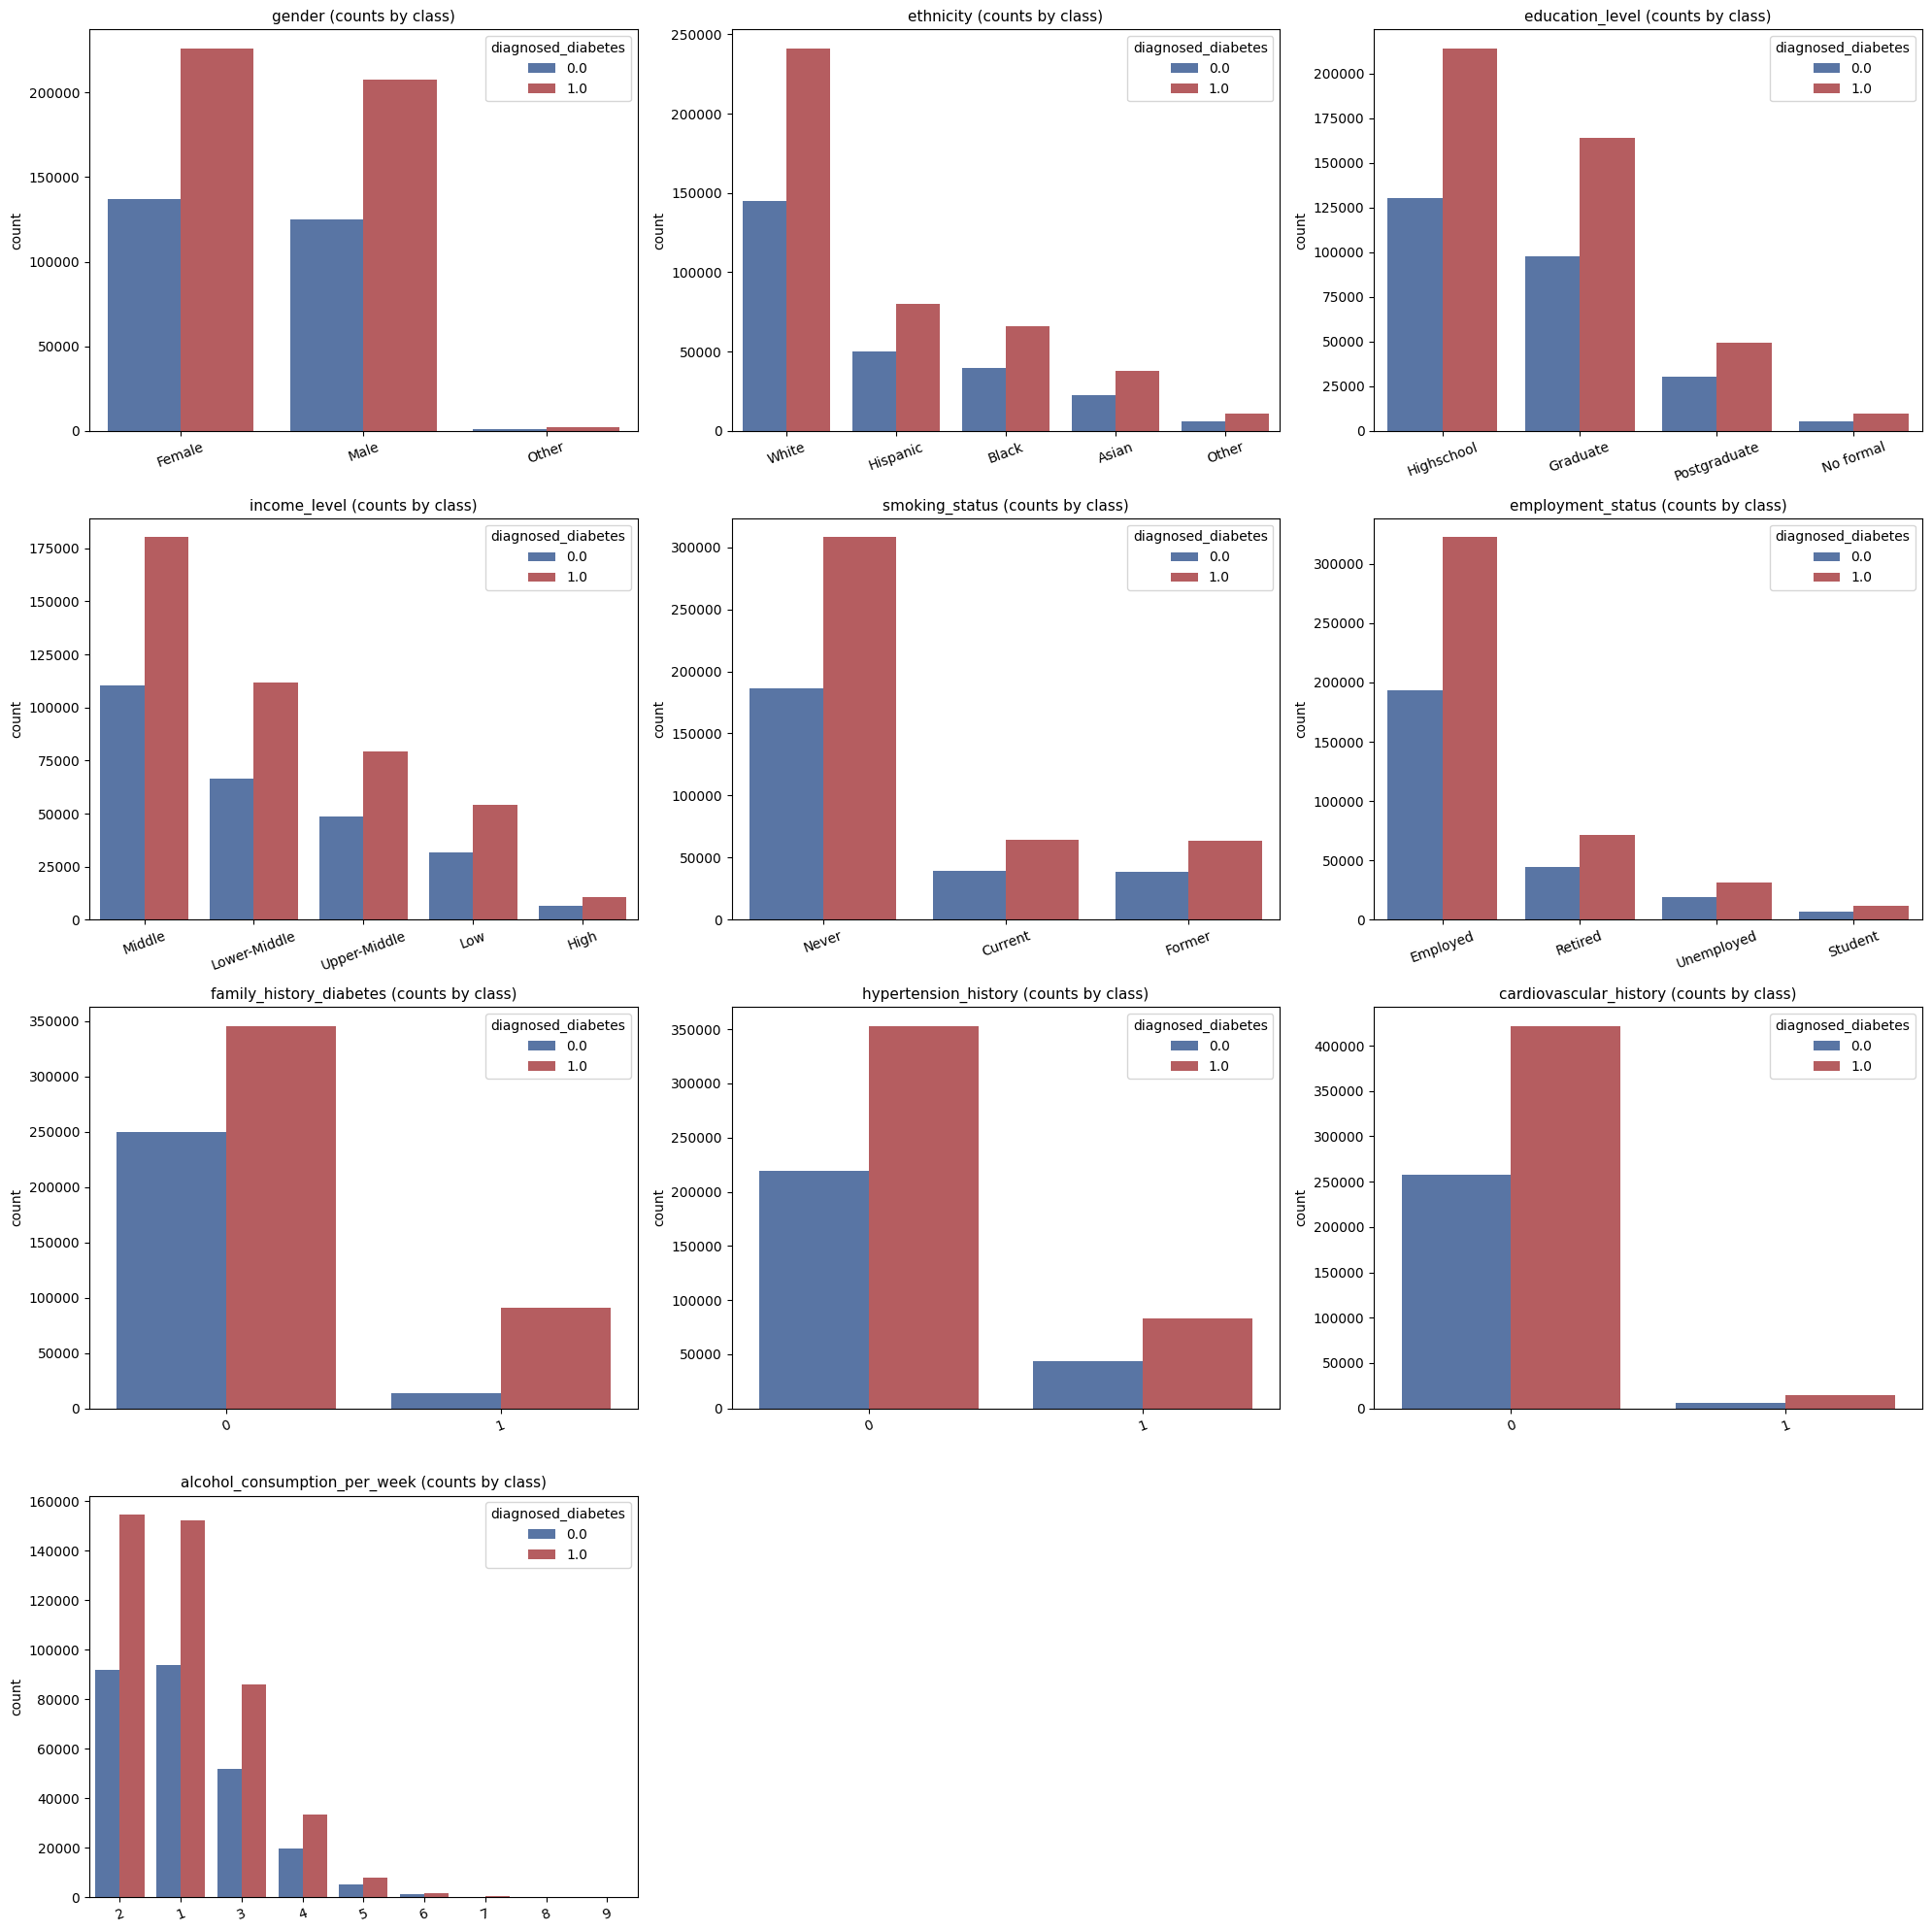

In [20]:
n_cols = 3
n_rows = 4
plt.figure(figsize=(20, 20))

for i, col in enumerate(cat_like):

    plt.subplot(n_rows, n_cols, i + 1)
    
    order = df[col].value_counts().index
    
    sns.countplot(x=col, hue=TARGET, data=df, order=order,
                  palette=['#4C72B0', '#C44E52'])
    
    plt.title(f'{col} (counts by class)', fontsize=11)
    plt.xlabel('')
    plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

**Observations:**

- The **positive class (1) dominates every category**, consistent with the global **62%/38%** target split.
- `gender`, `ethnicity`, `education_level`, `income_level`: bar heights mirror each level's marginal frequency.
- `alcohol_consumption_per_week`: concentrated on **values 1, 2, 3**;
- Binary medical flags are heavily skewed toward 0: `family_history_diabetes`, `hypertension_history`, `cardiovascular_history`.

### 3.7 Numerical Features by Target Class

To see whether continuous features separate the two classes, we plot a **KDE per class**
for each feature. Features whose distributions are visibly shifted between class 0 and
class 1 carry direct predictive signal.

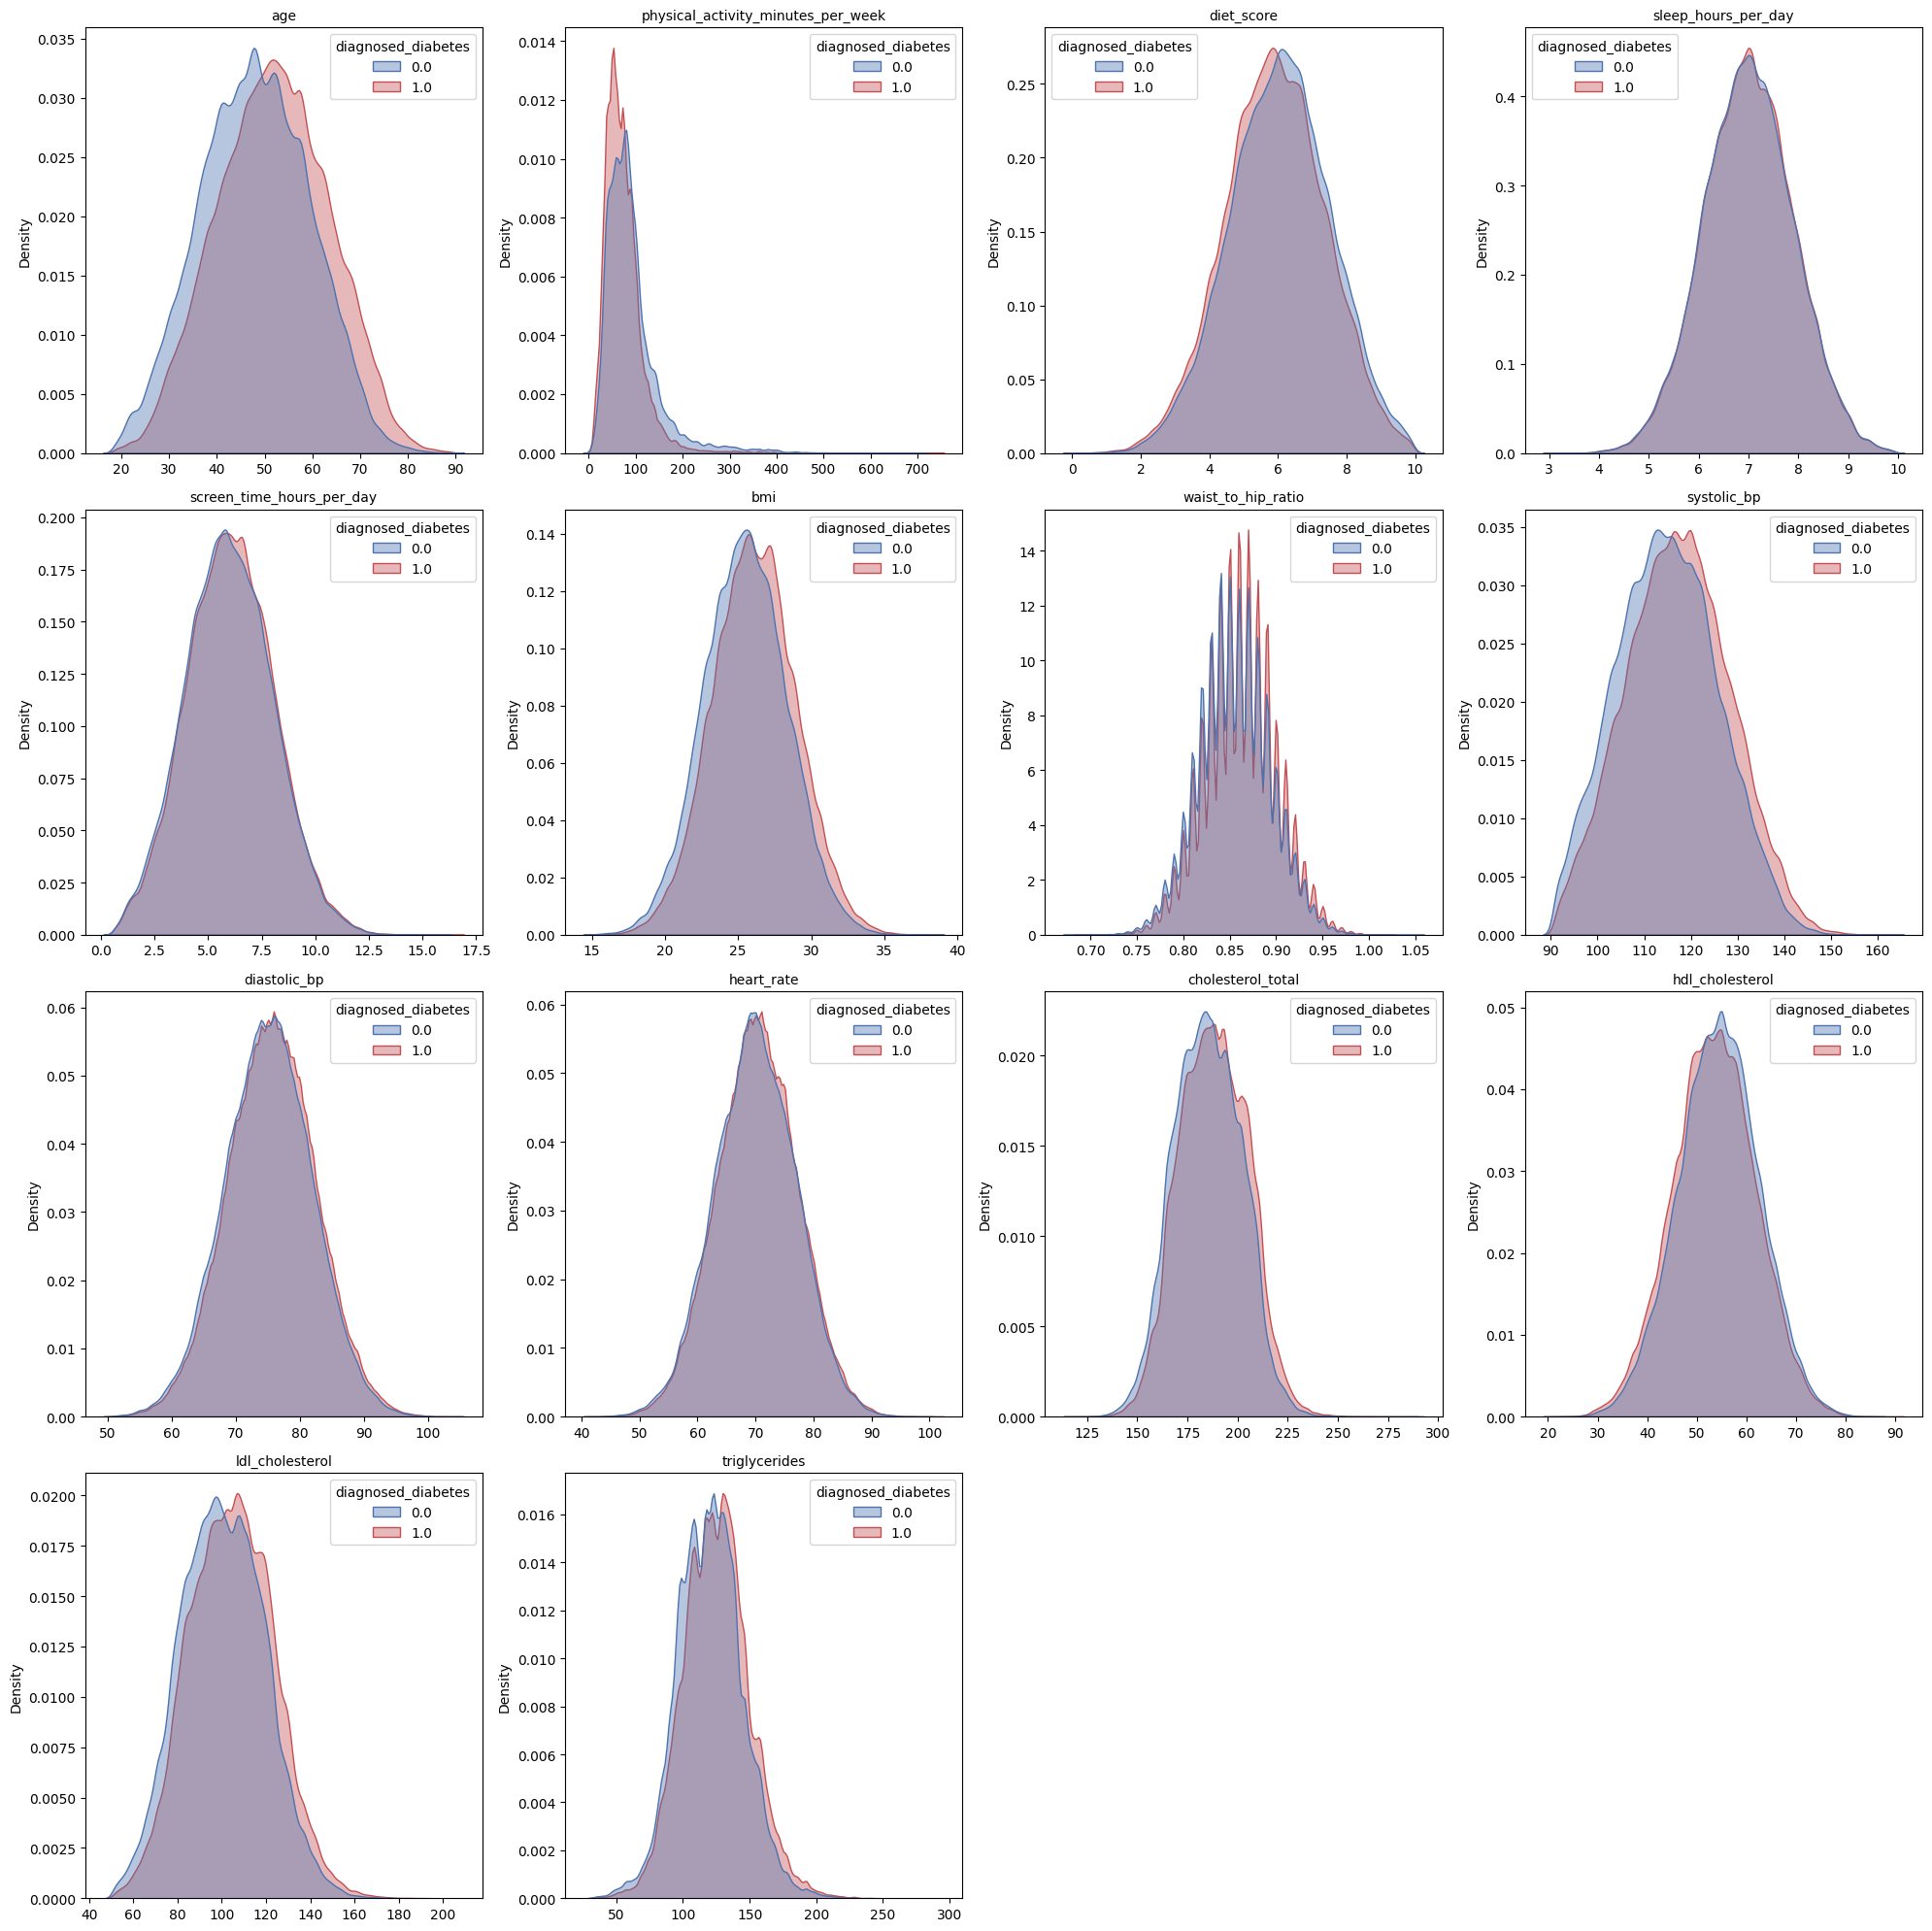

In [21]:
# KDE plot per class for each continuous numerical feature
n_cols = 4
n_rows = 4
plt.figure(figsize=(20, 20))

for i, col in enumerate(numeric_cols):
    # Attiva il subplot corrispondente (indice 1-based)
    plt.subplot(n_rows, n_cols, i + 1)
    
    # Seaborn disegna nel subplot corrente
    sns.kdeplot(data=df, x=col, hue=TARGET,
                common_norm=False, fill=True, alpha=0.4,
                palette=['#4C72B0', '#C44E52'])
    
    # Formattazione
    plt.title(col, fontsize=10)
    plt.xlabel('')

plt.tight_layout()
plt.show()

### 3.8 Correlation Analysis

A correlation heatmap helps detect:
- **redundant features** (very high pairwise correlations → multicollinearity),
- **direct signals to the target** (which feature correlates most with
  `diagnosed_diabetes`).

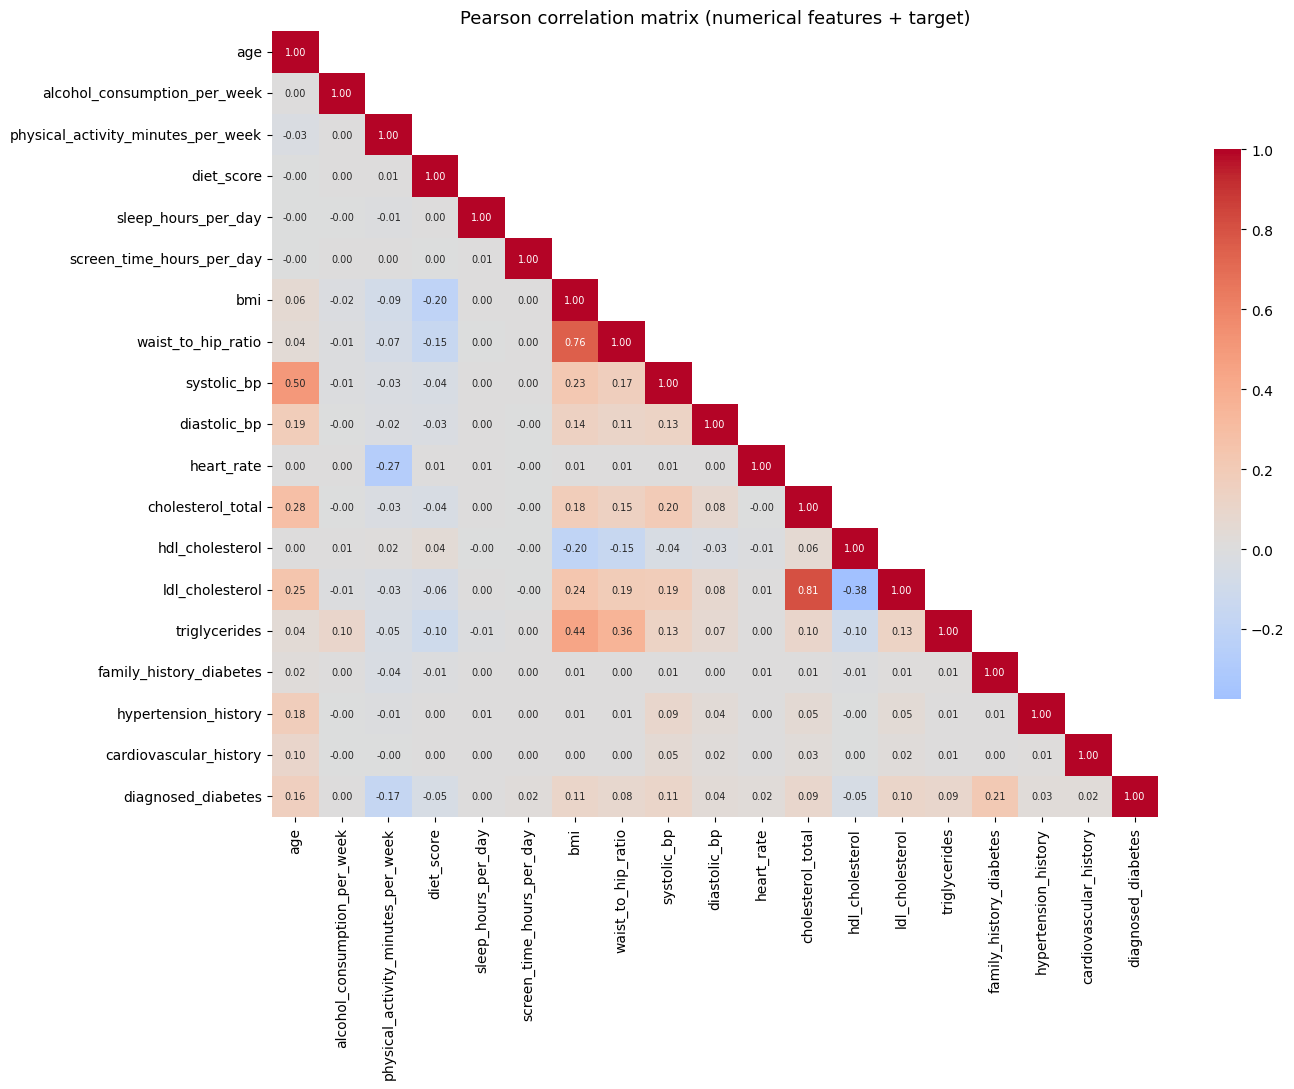

In [22]:
# Pearson correlation matrix for numeric features (binary flags + target included)
num_for_corr = [c for c in df.select_dtypes(include=['int64', 'float64']).columns
                if c != 'id']
corr = df[num_for_corr].corr()

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            annot=True, fmt='.2f', annot_kws={'size': 7},
            cbar_kws={'shrink': 0.7})
plt.title('Pearson correlation matrix (numerical features + target)', fontsize=13)
plt.tight_layout()
plt.show()

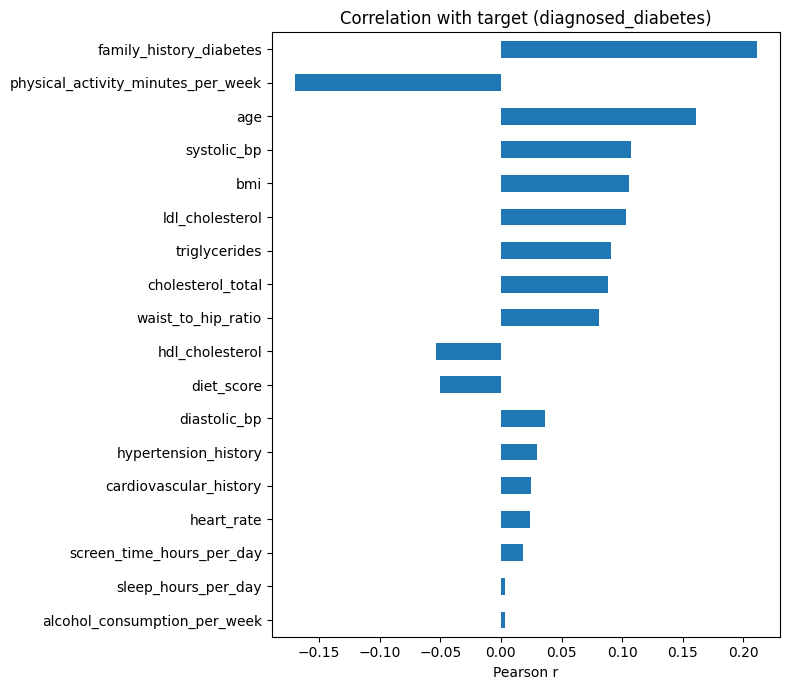

In [23]:
target_corr = (corr[TARGET]
                 .drop(TARGET)
                 .sort_values(key=abs, ascending=True))

# Inizializza la figura
plt.figure(figsize=(8, 7))

# Crea il subplot singolo (1 riga, 1 colonna, indice 1)
plt.subplot(1, 1, 1)

# Il metodo plot di Pandas userà automaticamente il subplot attivo
target_corr.plot(kind='barh')

# Formattazione tramite l'interfaccia pyplot
plt.title(f'Correlation with target ({TARGET})')
plt.xlabel('Pearson r')

plt.tight_layout()
plt.show()

In [24]:
target_corr.round(3)

alcohol_consumption_per_week          0.003
sleep_hours_per_day                   0.004
screen_time_hours_per_day             0.018
heart_rate                            0.024
cardiovascular_history                0.025
hypertension_history                  0.030
diastolic_bp                          0.036
diet_score                           -0.050
hdl_cholesterol                      -0.053
waist_to_hip_ratio                    0.081
cholesterol_total                     0.088
triglycerides                         0.091
ldl_cholesterol                       0.103
bmi                                   0.106
systolic_bp                           0.107
age                                   0.161
physical_activity_minutes_per_week   -0.170
family_history_diabetes               0.211
Name: diagnosed_diabetes, dtype: float64

**Observations (correlation with target):**

- **All correlations are weak**: the strongest is `family_history_diabetes`.
- **Top positive drivers**: `family_history_diabetes`, `age`, `systolic_bp`, `bmi`, `ldl_cholesterol`, `triglycerides`, `cholesterol_total`, `waist_to_hip_ratio`.
- **Top negative drivers**: `physical_activity_minutes_per_week`, `hdl_cholesterol`, `diet_score`.
- **Near-zero correlation**: `sleep_hours_per_day`, `alcohol_consumption_per_week`.
- The binary flags `hypertension_history` and `cardiovascular_history` are surprisingly low individually.

## **4. Preprocessing Dataset**

Based on the EDA conclusions, this section transforms the raw dataframe into a
**model-ready** matrix.

Pipeline:
1. Drop `id` (non-predictive).
2. Encode categorical variables (ordinal where applicable, one-hot otherwise).
3. Apply a robust scaler to continuous features (saved separately — tree models
   will use the unscaled version).

### 4.1 Drop the `id` and TARGET column

`id` is a unique row identifier with no predictive value. We keep it aside in case it
is needed for joins later, but it must not enter the feature matrix.

In [25]:
print(f"Before dropping id: {df.shape}")
X = df.drop(columns=['id', TARGET]).copy()
print(f"After dropping id: {X.shape}")

Before dropping id: (700000, 26)
After dropping id: (700000, 24)


### 4.2 Encoding of categorical features

- **Ordinal encoding** for variables with a clear order:
  - `education_level` : *No formal* < *Highschool* < *Graduate* < *Postgraduate*
  - `income_level`    : *Low* < *Lower-Middle* < *Middle* < *Upper-Middle* < *High*
- **One-hot encoding** for purely nominal variables:
  - `gender`, `ethnicity`, `smoking_status`, `employment_status`

The binary medical flags (`family_history_diabetes`, `hypertension_history`,
`cardiovascular_history`) are already 0/1 and require no encoding.

In [26]:
# Ordinal encoding
ordinal_cols = ['education_level', 'income_level']
ordinal_categories = [
    ['No formal', 'Highschool', 'Graduate', 'Postgraduate'], # education_level
    ['Low', 'Lower-Middle', 'Middle', 'Upper-Middle', 'High'], # income_level
]

ord_enc = OrdinalEncoder(categories=ordinal_categories, dtype=np.int8)
X[ordinal_cols] = ord_enc.fit_transform(X[ordinal_cols])

# One-hot encoding 
nominal_cols = ['gender', 'ethnicity', 'smoking_status', 'employment_status']

ohe = OneHotEncoder(drop=None, sparse_output=False, dtype=np.int8)
ohe_array   = ohe.fit_transform(X[nominal_cols])
ohe_columns = ohe.get_feature_names_out(nominal_cols)

df_ohe  = pd.DataFrame(ohe_array, columns=ohe_columns, index=X.index)
X = pd.concat([X.drop(columns=nominal_cols), df_ohe], axis=1)

print(f"Shape after encoding: {X.shape}")
X.dtypes.value_counts()

Shape after encoding: (700000, 35)


int8       17
int64      13
float64     5
Name: count, dtype: int64

### 4.3 Dataset split & validation strategy
To ensure a robust evaluation the complete dataset (totaling **700,000 rows**) is managed according to the following splitting and validation architecture:

#### 1. Initial Split (Hold-Out Method)
The primary dataset is partitioned into two distinct subsets:
* **Training Set (~67% - 469K rows):** Used exclusively for model training, hyperparameter tuning, and architecture selection.
* **Test Set (~23% - 231K rows):** Kept completely isolated. It will be touched **only once at the very end of the workflow** for the final evaluation, accurately simulating production behavior on unseen data.

#### 2. Validation & Model Selection (Cross-Validation)
To leverage the training data efficiently without overfitting during the exploration phase (e.g., during `GridSearchCV`), a **5-fold Stratified K-Fold Cross-Validation** strategy is applied directly to the Training Set:
* The training data is dynamically split into 5 folds, preserving the original class distribution (stratification).
* Iteratively, 4 folds are used for fitting the model, while the remaining fold acts as a temporary **Validation Set**.
* This approach ensures a reliable framework for:
    * Hyperparameter tuning.
    * Direct model comparison.
    * Ensemble building.

In [27]:
y = df[TARGET]
print(y.shape)

(700000,)


In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = RANDOM_STATE, train_size = TRAIN_SIZE)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(469000, 35) (231000, 35) (469000,) (231000,)


## **5. Models & Parameters Definition**

### 5.1 Define models and parameters
Prepare the hyperparameter ranges for the modules

In [29]:
model_lbls = ['dt' # decision tree
             ,'nb' # gaussian naive bayes
      #       ,'lp'   # linear perceptron
      #        ,'svc'  # support vector # deactivate if running time becomes too long
             ,'knn'  # k nearest neighbours
             ,'adb'  # adaboost
             ,'rf'   # random forest
             ,'xgb'
             ,'lgbm'
             ,'catb'
            ]

models = {
    'dt': {'name': 'Decision Tree       ',
           'estimator': DecisionTreeClassifier(random_state=RANDOM_STATE), 
           'param': [{'max_depth': [*range(1,20)],
                      'class_weight':[None,'balanced']}],
          },
    'nb': {'name': 'Gaussian Naive Bayes',
           'estimator': GaussianNB(),
           'param': [{'var_smoothing': [10**exp for exp in range(-3,-13,-1)]}]
          },
    'lp': {'name': 'Linear Perceptron   ',
           'estimator': Perceptron(random_state=RANDOM_STATE),
           'param': [{'early_stopping': [True,False],
                      'class_weight':[None,'balanced']}],
          },
    'svc':{'name': 'Support Vector      ',
           'estimator': SVC(random_state=RANDOM_STATE), 
           'param': [{'kernel': ['rbf'], 
                    'gamma': [1e-3, 1e-4],
                    'C': [1, 10, 100],
                    },
                    {'kernel': ['linear'],
                     'C': [1, 10, 100],                     
             },
                   ]
          },
    'knn':{'name': 'K Nearest Neighbor ',
           'estimator': KNeighborsClassifier(),
           'param': [{'n_neighbors': list(range(1,7))}]
       },
    'adb':{'name': 'AdaBoost           ',
           'estimator': AdaBoostClassifier(random_state=RANDOM_STATE),
           'param': [{'n_estimators':[10,20,30,40,50]
                     ,'learning_rate':[0.2,0.5,1,1.5]}]
          },
    'rf': {'name': 'Random forest      ',
           'estimator': RandomForestClassifier(random_state=RANDOM_STATE),
           'param': [{'max_depth': [*range(4,10)]
                     ,'n_estimators':[*range(10,60,10)]}]
          },
    'xgb': {'name': 'XGboost           ',
           'estimator': XGBClassifier(random_state=RANDOM_STATE, objective='binary:logistic'),
           'param': [{'n_estimators': [300, 600]
                     ,'learning_rate':[0.02, 0.05, 0.1]
                     ,'min_child_weight': [1, 5, 10]
                     ,'max_depth': [3, 6, 10]
                     }]
          },
    'lgbm': {'name': 'LGBMClassifier   ',
             'estimator': lgb.LGBMClassifier(objective="binary", metric="auc", random_state=RANDOM_STATE),
             'param': [{
                "n_estimators": [100, 200, 300],
                "learning_rate":[0.02, 0.05, 0.1],
                "num_leaves": [31, 63, 127],
                "max_depth": [-1, 3]
                }]
           },
    'catb': {'name': 'CatBoostClassifier',
             'estimator':  CatBoostClassifier(loss_function='Logloss', random_state=RANDOM_STATE, verbose = 0),
             'param': [{
                'iterations': [100, 200, 400],
                'learning_rate': [0.01, 0.1, 0.2],
                'depth': [3, 6],
                'auto_class_weights' : ['None', 'Balanced']
             }]
            }
}

### 5.2 Set the score functions

In [30]:
#scorings = ['accuracy','precision_macro','recall_macro','f1_macro','roc_auc']
scorings = ['roc_auc']

In [31]:
trials = {lbl: len(list(ParameterGrid(models[lbl]['param']))) for lbl in models.keys()}
trials

{'dt': 38,
 'nb': 10,
 'lp': 4,
 'svc': 9,
 'knn': 6,
 'adb': 20,
 'rf': 30,
 'xgb': 54,
 'lgbm': 54,
 'catb': 36}

### 5.3 Define the result dataframe
We define two structure to store all the data during the training:
- we prepare an empty list `clfs` to store all the fitted models
- we prepare an empty DataFrame which will collect the results of the fittings with each combination of parameters. The dataframe columns are `'scoring','model','best_params','accuracy','precision_macro','recall_macro','f1_macro','roc_auc'`

In [32]:
clfs = []
results = pd.DataFrame(columns=['scoring','model','best_params'#,'fit+score_time'
                                ,'accuracy','precision_macro','recall_macro','f1_macro','roc_auc'])

## **6. Model Training**

In [33]:
skf = StratifiedKFold(n_splits=N_FOLDS, random_state=RANDOM_STATE, shuffle=True)

for scoring in scorings:
    print(f"Scoring: {scoring}")
    for m in model_lbls:
        print(f"model: {m}")
        clf = GridSearchCV(models[m]['estimator'], models[m]['param'], cv=skf,
                           scoring = scoring, 
                           verbose = 10
                           )

        clf.fit(X_train, y_train)   
        clfs.append(clf)
        y_true, y_pred = y_test, clf.predict(X_test)
        # y_preds.append(y_pred)

        # Classification report
        cr = classification_report(y_true,y_pred, output_dict=True
                                   , zero_division=1
                                   )

        # Scores for ROC AUC
        y_scores = clf.predict_proba(X_test)[:, 1]

        # Compute ROC AUC
        roc_auc = roc_auc_score(y_true, y_scores)
        
        #roc_auc = roc_auc_score(y_true,y_pred)
        results.loc[len(results)] = [scoring,models[m]['name'],clf.best_params_
                                    # ,(clf.cv_results_['mean_fit_time'].sum()+clf.cv_results_['mean_score_time'].sum())*n_splits
                                    ,cr['accuracy']
                                    ,cr['macro avg']['precision']
                                    ,cr['macro avg']['recall']
                                    ,cr['macro avg']['f1-score']
                                    ,roc_auc]

Scoring: roc_auc
model: dt
Fitting 5 folds for each of 38 candidates, totalling 190 fits
[CV 1/5; 1/38] START class_weight=None, max_depth=1.............................
[CV 1/5; 1/38] END class_weight=None, max_depth=1;, score=0.576 total time=   0.4s
[CV 2/5; 1/38] START class_weight=None, max_depth=1.............................
[CV 2/5; 1/38] END class_weight=None, max_depth=1;, score=0.578 total time=   0.4s
[CV 3/5; 1/38] START class_weight=None, max_depth=1.............................
[CV 3/5; 1/38] END class_weight=None, max_depth=1;, score=0.578 total time=   0.4s
[CV 4/5; 1/38] START class_weight=None, max_depth=1.............................
[CV 4/5; 1/38] END class_weight=None, max_depth=1;, score=0.579 total time=   0.4s
[CV 5/5; 1/38] START class_weight=None, max_depth=1.............................
[CV 5/5; 1/38] END class_weight=None, max_depth=1;, score=0.577 total time=   0.4s
[CV 1/5; 2/38] START class_weight=None, max_depth=2.............................
[CV 1/5; 2

## **7. Evaluation & Comparison**

In [34]:
for score in scorings:
    scoring_filter = score
    display(results[results.scoring==scoring_filter]\
                .sort_values(by=scoring_filter,ascending=False)\
                .drop('scoring',axis=1)\
                .style.format(precision=3)\
                    .set_caption('Results for scoring "{}"'.format(scoring_filter))
    )

,model,best_params,accuracy,precision_macro,recall_macro,f1_macro,roc_auc
7,CatBoostClassifier,"{'auto_class_weights': 'Balanced', 'depth': 6, 'iterations': 400, 'learning_rate': 0.2}",0.655,0.652,0.662,0.648,0.725
6,LGBMClassifier,"{'learning_rate': 0.1, 'max_depth': -1, 'n_estimators': 300, 'num_leaves': 31}",0.683,0.661,0.631,0.634,0.725
5,XGboost,"{'learning_rate': 0.05, 'max_depth': 6, 'min_child_weight': 10, 'n_estimators': 600}",0.684,0.661,0.631,0.634,0.725
3,AdaBoost,"{'learning_rate': 1.5, 'n_estimators': 50}",0.666,0.639,0.607,0.607,0.701
4,Random forest,"{'max_depth': 9, 'n_estimators': 50}",0.660,0.646,0.574,0.555,0.696
0,Decision Tree,"{'class_weight': None, 'max_depth': 9}",0.662,0.633,0.601,0.600,0.692
1,Gaussian Naive Bayes,{'var_smoothing': 1e-05},0.638,0.618,0.621,0.619,0.681
2,K Nearest Neighbor,{'n_neighbors': 6},0.580,0.560,0.562,0.560,0.584


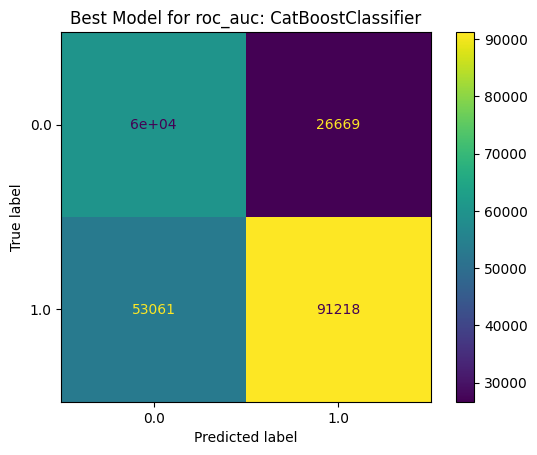

In [35]:
for score in scorings:
    scoring_filter = score
    # bests[score] = results.loc[results.scoring==scoring_filter,scoring_filter].idxmax(axis=0)
    best_row = results.loc[results.scoring==scoring_filter,scoring_filter].idxmax(axis=0)
    disp = ConfusionMatrixDisplay.from_estimator(X=X_test, y=y_test, estimator = clfs[best_row])
    # disp.ax_.set_title("Best Model for {}: {}".format(score,results.at[bests[score],'model']))
    disp.ax_.set_title("Best Model for {}: {}".format(score,results.at[best_row,'model']))

## **8. References**
- **Diabetes Prediction Challenge**: https://www.kaggle.com/competitions/playground-series-s5e12/data
- **Original Diabetes Health Indicators Dataset**: https://www.kaggle.com/datasets/mohankrishnathalla/diabetes-health-indicators-dataset/data
- **Hyperparameter LightGBM**: https://www.kaggle.com/code/mustafagerme/hyperparameter-tuning-with-gridsearchcv-for-lgbm
- **Hyperparameter XGBoost**: https://www.kaggle.com/code/tilii7/hyperparameter-grid-search-with-xgboost
- **LightGBM**: https://www.kaggle.com/code/prashant111/lightgbm-classifier-in-python
- 